Machine Learning Modeling, Comparison, and Interpretability

At this process, we need integrate the two results (user_micro_behavior_features.csv & bgnbd_features_for_xgboost.csv) to construct a two-stage hybrid prediction model combining BG/NBD probabilistic prior with user micro behaviour (PV, Cart, Favorite). In that case, we will take entire notebook into 6 steps:

1.Dual-source data alignment and matrix merging

2.Definition of feature space (X) and prediction target (y)

3.Train-test split

4.XGBoost hybrid regression model training and tuning

5.Performance comparison of three models (BG/NBD vs. behavioral-only vs. hybrid model)

6.Feature importance and SHAP interpretability analysis (Feature Attribution)

1.Dual-source data alignment and matrix merging

In [1]:
import pandas as pd
import numpy as np

# read 2 result
rft_data = pd.read_csv('output/bgnbd_features_for_xgboost.csv')
feature_data = pd.read_csv('output/user_micro_behavior_features.csv')

# standardized processing aviod user_id of rft table existing index or first column undefined
if 'user_id' not in rft_data.columns:
    rft_data.rename(columns={rft_data.columns[0]: 'user_id'}, inplace=True)
if 'user_id' not in feature_data.columns:
    feature_data.rename(columns={feature_data.columns[0]: 'user_id'}, inplace=True)

# inner merge according to user_id
hybrid_data = pd.merge(rft_data, feature_data, on='user_id', how='inner')

# test
print(hybrid_data.head())

   user_id  frequency_cal  recency_cal  T_cal  frequency_holdout  \
0        2            0.0          0.0    2.0                2.0   
1        4            1.0          2.0    2.0                0.0   
2       11            0.0          0.0    5.0                0.0   
3       16            0.0          0.0    0.0                1.0   
4       24            0.0          0.0    3.0                0.0   

   duration_holdout  prob_user_alive  bg_nbd_predicted_purchases  \
0               3.0              1.0                    0.466405   
1               3.0              1.0                    0.863542   
2               3.0              1.0                    0.333829   
3               3.0              1.0                    0.634356   
4               3.0              1.0                    0.411881   

   pv_count_cal  cart_count_cal  fav_count_cal  buy_count_cal  \
0            27               0              7              2   
1           205              12              0      

2.Definition of feature space (X) and prediction target (y)

In order to conduct ablation studies (comparative experiments), we need to set 3 sets of feature spaces:

(1)Baseline model1: BG/NBD probailistic prediction
(2)Comparsion model2: Pure Micro-behaviour XGBoost
(3)Final model: Two-Stage Hybrid XGBoost model

In [2]:
# aviod outliers
hybrid_data['cart_to_buy_ratio'] = np.log1p(hybrid_data['buy_count_cal'] / (hybrid_data['cart_count_cal'] + 1.0))
hybrid_data['pv_to_buy_ratio'] = np.log1p(hybrid_data['buy_count_cal'] / (hybrid_data['pv_count_cal'] + 1.0))
hybrid_data['pv_count_log'] = np.log1p(hybrid_data['pv_count_cal'])
hybrid_data['cart_count_log'] = np.log1p(hybrid_data['cart_count_cal'])

# define predicted target Y (Holdout Period - 3days as targets)
y = hybrid_data['frequency_holdout']

# define feature matrix X (mixed feature space)
probailistic_feature = ['frequency_cal',
    'recency_cal',
    'T_cal',
    'prob_user_alive',
    'bg_nbd_predicted_purchases'
]

# micro-feature behaviour stream
micro_feature = [
    'pv_count_log',
    'cart_count_log',
    'fav_count_cal',
    'buy_count_cal',
    'cart_to_buy_ratio',
    'pv_to_buy_ratio'
]

# hybrid-feature behaviour stream
hybrid_feature = probailistic_feature + micro_feature

# extract micro-feature matrix and hybrid-feature matrix
x_micro = hybrid_data[micro_feature]
x_hybrid = hybrid_data[hybrid_feature]

# test
print(x_micro.head())
print(x_hybrid.head())

   pv_count_log  cart_count_log  fav_count_cal  buy_count_cal  \
0      3.332205        0.000000              7              2   
1      5.327876        2.564949              0              4   
2      4.812184        1.386294              2              1   
3      4.077537        0.693147              2              1   
4      2.995732        1.098612              0              1   

   cart_to_buy_ratio  pv_to_buy_ratio  
0           1.098612         0.068993  
1           0.268264         0.019231  
2           0.223144         0.008097  
3           0.405465         0.016807  
4           0.287682         0.048790  
   frequency_cal  recency_cal  T_cal  prob_user_alive  \
0            0.0          0.0    2.0              1.0   
1            1.0          2.0    2.0              1.0   
2            0.0          0.0    5.0              1.0   
3            0.0          0.0    0.0              1.0   
4            0.0          0.0    3.0              1.0   

   bg_nbd_predicted_purcha

3.Train-test split

In order to keep a fair evaluation of the 3 models. we need split total sample of 1,530 users into training and test sets using a fixed random seed (e.g., an 80%/20% split).

Training set (80%): use to fit XGBoost decision trees and iptimize leaf node weights
Test set (20%): Space the holdout, evaluate the MAE and RMSE between Pure-BG/NBD, Pure Micro-behaviour XGBoost and Two-Stage Hybrid XGBoost model

In [3]:
# import split-function module
from sklearn.model_selection import train_test_split

# set a random seed to ensure experiment could be repeat
random_seed = 14

# split mixed feature sets- for 3 models training
# x_hybrid: feature data(questions), y: splited label vector(answers)
x_train_hyb, x_test_hyb, y_train_answ, y_test_answ = train_test_split(x_hybrid, y, test_size=0.2, random_state=random_seed)

# split micro-feature behaviour sets (keep the same index with hybrid sets above) = # split mixed feature sets- for 3 models training above
x_train_micro = x_micro.loc[x_train_hyb.index]
x_test_micro = x_micro.loc[x_test_hyb.index]

# extract the Pure-BG/NBD prediction baseline from test set
bgnbd_pred_test = hybrid_data.loc[x_test_hyb.index, 'bg_nbd_predicted_purchases']

# test
print(bgnbd_pred_test.head())

217960    0.618080
116001    0.466405
81931     0.368771
319940    0.411881
36637     0.618080
Name: bg_nbd_predicted_purchases, dtype: float64


4.XGBoost hybrid regression model training and tuning 

According to the regularized boosting tree theory of Chen & Guestrin(20116), we need fit the MSE objective function and set hyperparameters to prevent overfitting：

In [4]:
# install xgboost
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [5]:
# import xgboost and parameters setting modules
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# set regression hyperparameters
xgb_parameters = {
    'objective': 'reg:squarederror',
    'n_estimators': 150,
    'learning_rate': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': random_seed,
    'n_jobs': -1
}

# training model-only micro XGBoost
model_micro = xgb.XGBRegressor(**xgb_parameters) # unpack the dictionary (xgb_parameters)
model_micro.fit(x_train_micro, y_train_answ)
y_pred_micro = model_micro.predict(x_test_micro)

# training model hybrid XGBoost
model_hybrid = xgb.XGBRegressor(**xgb_parameters)
model_hybrid.fit(x_train_hyb, y_train_answ)
y_pred_hybrid = model_hybrid.predict(x_test_hyb)

# test
print(y_pred_hybrid[:5])

[0.5585971  0.50373775 0.4554659  0.44889024 0.62803614]


5.Performance comparison of three models (BG/NBD vs. behavioral-only vs. hybrid model)

Construct a comparative table by calculating the Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) on the test set.

In [6]:
# import pandas module for comparsion
import pandas

# calculate the MAE and RMSE of 3 models in test set
#BG/NBD
mae_bgnbd = mean_absolute_error(y_test_answ, bgnbd_pred_test)
rmse_bgnbd = np.sqrt(mean_squared_error(y_test_answ, bgnbd_pred_test))
#Pure-XBGoost
mae_micro = mean_absolute_error(y_test_answ, y_pred_micro)
rmse_micro = np.sqrt(mean_squared_error(y_test_answ, y_pred_micro))
#Hybrid-XGBoost
mae_hybrid = mean_absolute_error(y_test_answ, y_pred_hybrid)
rmse_hybrid = np.sqrt(mean_squared_error(y_test_answ, y_pred_hybrid))

# create comparison table
comparison_table = pd.DataFrame({
    'Model': [
        '1. Pure BG/NBD (Baseline)',
        '2. Micro-Behavior Only XGBoost',
        '3. Hybrid XGBoost (BG/NBD + Micro)'
    ],
    'MAE': [mae_bgnbd, mae_micro, mae_hybrid],
    'RMSE': [rmse_bgnbd, rmse_micro, rmse_hybrid],
    'MAE Improvement vs Baseline (%)': [
        0.0,
        (mae_bgnbd - mae_micro) / mae_bgnbd * 100,
        (mae_bgnbd - mae_hybrid) / mae_bgnbd * 100
    ],
    'RMSE Improvement vs Baseline (%)': [
        0.0,
        (rmse_bgnbd - rmse_micro) / rmse_bgnbd * 100,
        (rmse_bgnbd - rmse_hybrid) / rmse_bgnbd * 100
    ]
})

# test
print(comparison_table.round(4).to_string(index=False)) # convert DataFrame into string and hide index

                             Model    MAE   RMSE  MAE Improvement vs Baseline (%)  RMSE Improvement vs Baseline (%)
         1. Pure BG/NBD (Baseline) 0.6261 0.7392                           0.0000                            0.0000
    2. Micro-Behavior Only XGBoost 0.6231 0.7233                           0.4753                            2.1465
3. Hybrid XGBoost (BG/NBD + Micro) 0.6201 0.7197                           0.9557                            2.6439


6.Plot a bar chart comparing prediction errors and fitted values.

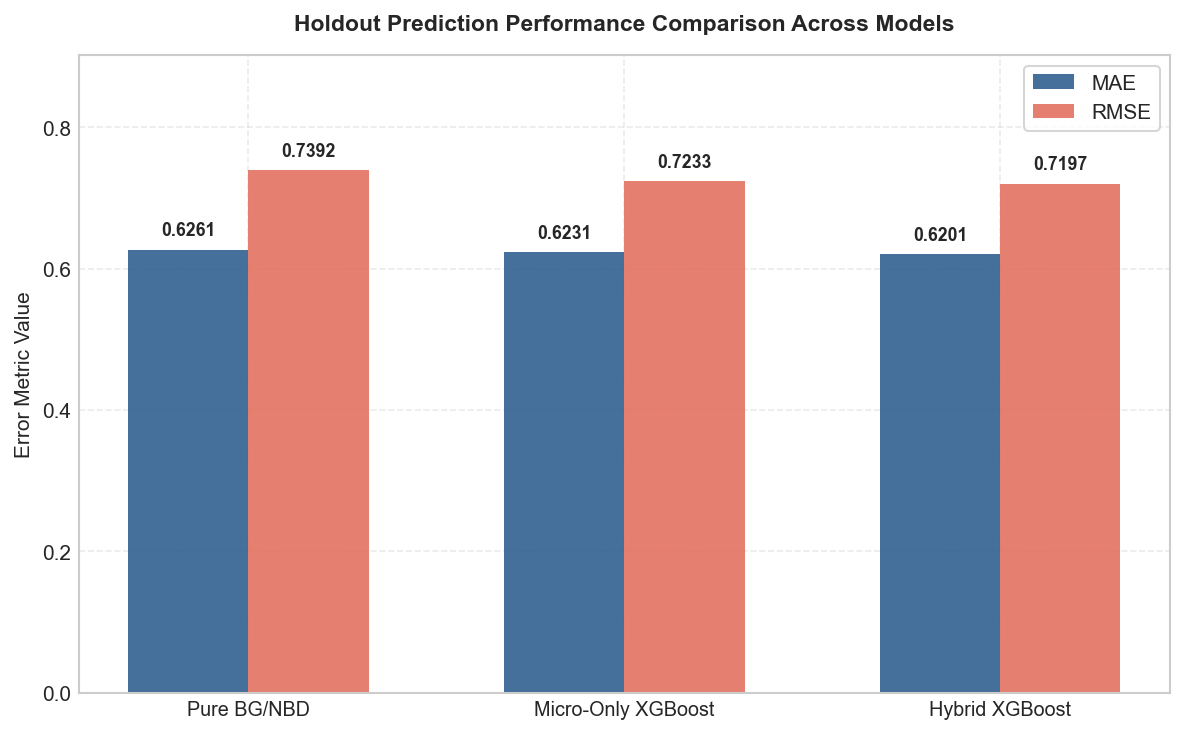

In [12]:
# import plot module
import matplotlib.pyplot as plt

# set plot parameters
plt.figure(figsize=(8, 5), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

models = ['Pure BG/NBD', 'Micro-Only XGBoost', 'Hybrid XGBoost']
mae_scores = [mae_bgnbd, mae_micro, mae_hybrid]
rmse_scores = [rmse_bgnbd, rmse_micro, rmse_hybrid]

x = np.arange(len(models))
width = 0.32

bars1 = plt.bar(x - width/2, mae_scores, width, label='MAE', color='#2b5c8f', alpha=0.88)
bars2 = plt.bar(x + width/2, rmse_scores, width, label='RMSE', color='#e26d5c', alpha=0.88)

for bar in list(bars1) + list(bars2):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f'{yval:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# dec
plt.title("Holdout Prediction Performance Comparison Across Models", fontsize=11, fontweight='bold', pad=12)
plt.ylabel("Error Metric Value", fontsize=10)
plt.xticks(x, models, fontsize=9.5)
plt.ylim(0, max(rmse_scores) * 1.22)
plt.legend(frameon=True, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4, axis='both')
plt.tight_layout()

# save
plt.savefig('figures/XGBoost/01_model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Hypothesis testing

To avoid potential randomness associated with white noise, we need to take a Hypothesis test. In order to prove Hybrid-XGBoost represent outstanding performance compared with BG/NBD, the hypothesis test should show P < 0.05 and Robustness assessment via 5-fold cross-validation should show a steady improvement compared with BG/NBD baseline.

In [11]:
# import modules
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

# calculate the absolute prediction residual for each individual sample and perform a paired test.
errors_bgnbd = np.abs(y_test_answ.values - bgnbd_pred_test.values)
errors_hybrid = np.abs(y_test_answ - y_pred_hybrid)

# perform a t-test
t_stat, p_val_ttest = stats.ttest_rel(errors_bgnbd, errors_hybrid, alternative='greater')
# Wilcoxon: Signed-rank test (more robust for skewed, discrete data)
w_stat, p_val_wilcoxon = stats.wilcoxon(errors_bgnbd, errors_hybrid, alternative='greater')

print("Hypothesis Test Result")
print(f"Paired t-test:       t = {t_stat:.4f},  p-value = {p_val_ttest:.4e}")
print(f"Wilcoxon Rank Test:  W = {w_stat:.4f},  p-value = {p_val_wilcoxon:.4e}")
if p_val_wilcoxon < 0.05:
    print("Result: p < 0.05，The hybrid model is significantly better than the pure BG/NBD model at the 95% confidence level (excluding random error)")

# 5-Fold Cross Validation Robustness
kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)
cv_mae_bgnbd, cv_mae_hybrid = [], []

for train_idx, val_idx in kf.split(x_hybrid):
    X_tr, X_val = x_hybrid.iloc[train_idx], x_hybrid.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # validation set BG/NBD prediction
    pred_bgnbd_val = hybrid_data.loc[X_val.index, 'bg_nbd_predicted_purchases']
    cv_mae_bgnbd.append(mean_absolute_error(y_val, pred_bgnbd_val))
    
    # validation set Hybrid XGBoost prediction
    model_cv = xgb.XGBRegressor(**xgb_parameters)
    model_cv.fit(X_tr, y_tr)
    pred_hyb_val = model_cv.predict(X_val)
    cv_mae_hybrid.append(mean_absolute_error(y_val, pred_hyb_val))

print("\5-Fold Cross Validation Robustness")
print(f"BG/NBD 5-Fold Avarage MAE:  {np.mean(cv_mae_bgnbd):.4f} (± {np.std(cv_mae_bgnbd):.4f})")
print(f"Hybrid 5-Fold Avarage MAE:  {np.mean(cv_mae_hybrid):.4f} (± {np.std(cv_mae_hybrid):.4f})")
print(f"5-Fold Avarage Improvement:     {(np.mean(cv_mae_bgnbd) - np.mean(cv_mae_hybrid))/np.mean(cv_mae_bgnbd)*100:.2f}%")

Hypothesis Test Result
Paired t-test:       t = 11.9723,  p-value = 2.6059e-33
Wilcoxon Rank Test:  W = 2880805992.5000,  p-value = 2.5736e-12
Result: p < 0.05，The hybrid model is significantly better than the pure BG/NBD model at the 95% confidence level (excluding random error)

5-Fold Cross Validation Robustness
BG/NBD 5-Fold Avarage MAE:  0.6242 (± 0.0013)
Hybrid 5-Fold Avarage MAE:  0.6177 (± 0.0015)
5-Fold Avarage Improvement:     1.05%


6.SHAP (SHapley Additive exPlanations) Global Interpretability

This section include parts below

(1)Global Feature Contribution Ranking (SHAP Bar plot): Quantifies the average absolute impact of features that impacts on each repeat purchases prediction.

(2)Positive/Negative drive direction and feature disturbution (SHAP Beeswarm plot): show how specific feature value could positively or negatively drive the likehood of repeat purchases.

(3)Marginal nonlinear effects of key feature (SHAP Dependence Plot): analyze the threshold inflection point of 'add-to-cart' behaviour, browing-to-conversion rates and prior probailities.

In [13]:
# pip SHAP module
%pip install shap


   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ----

In [15]:
# import module
import shap

# construct the TreeExplainer of Hybrid-XGBoost
tree_explainer = shap.TreeExplainer(model_hybrid)

# calculate the attribution values of Shapley
shap_values = tree_explainer(x_test_hyb)

# test
print(f'SHAP Dimension Matrix:{shap_values.values.shape}')

SHAP Dimension Matrix:(106056, 11)


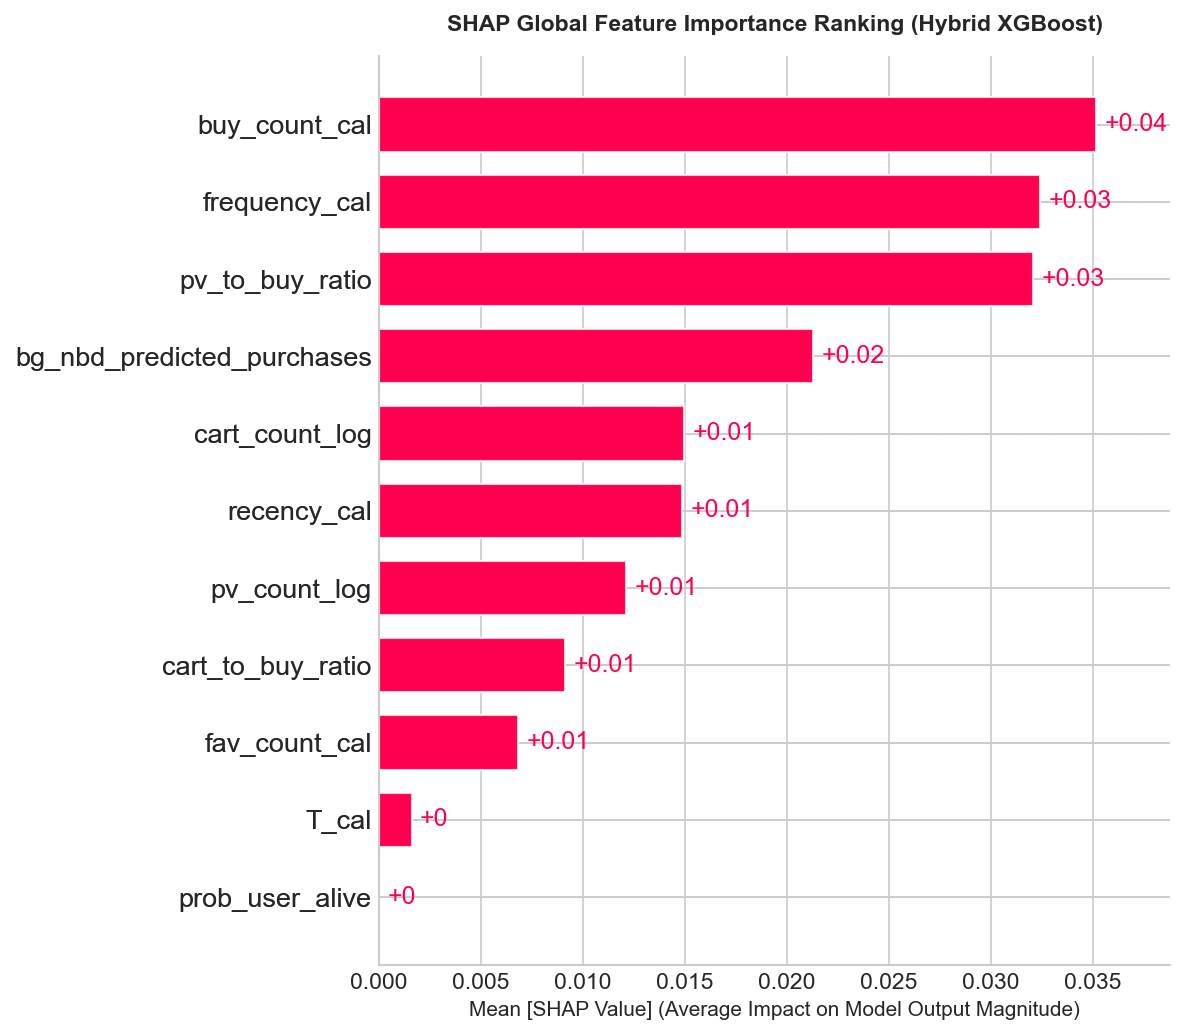

In [18]:
# 6.1plotting SHAP Global Feature Importance
# plot sets
plt.figure(figsize=(8,5), dpi=150)

# plot bar chart
shap.plots.bar(shap_values, max_display=12, show=False)

# dec
plt.title('SHAP Global Feature Importance Ranking (Hybrid XGBoost)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Mean [SHAP Value] (Average Impact on Model Output Magnitude)', fontsize=10)
plt.tight_layout()

# save
plt.savefig('figures/XGBoost/02_shap_feature_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()

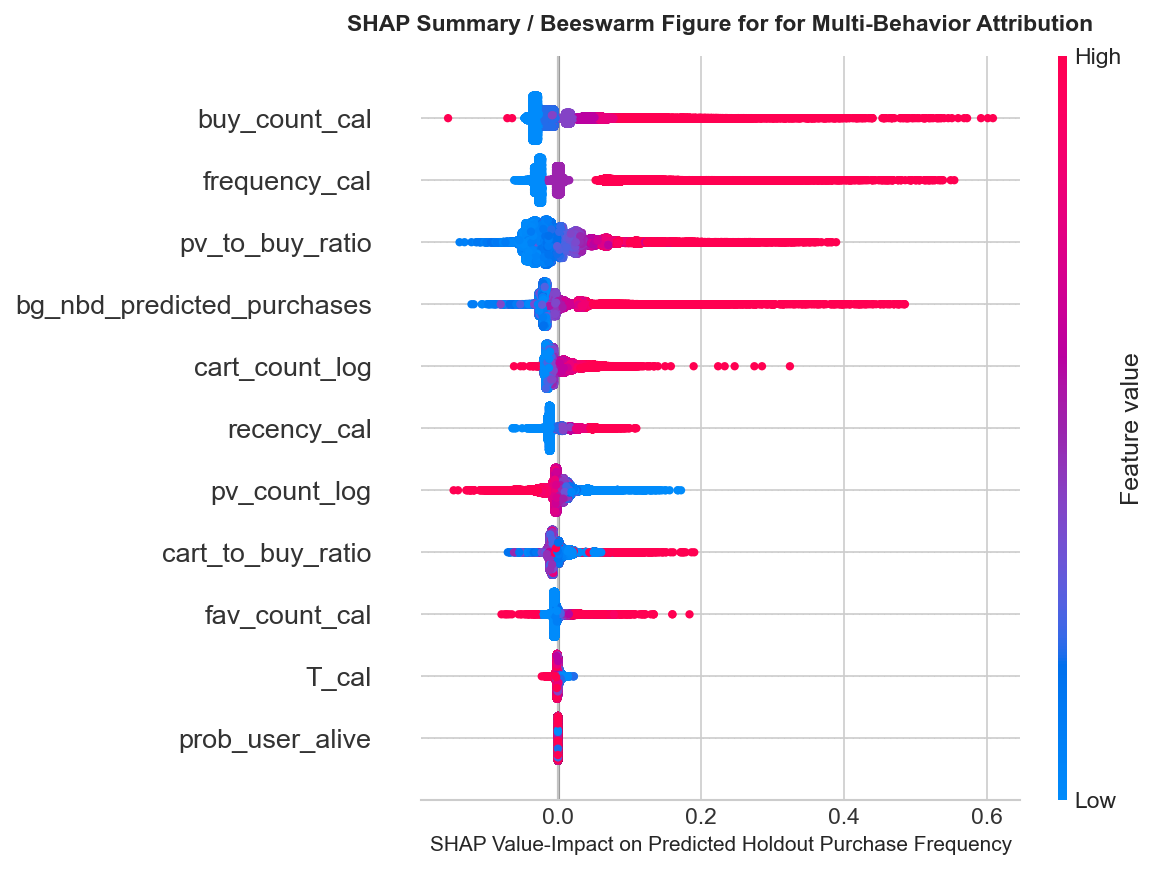

In [19]:
# 6.2 plot SHAP Summary / Beeswarm figure
# set plot parameters
plt.figure(figsize=(8,5), dpi=150)
shap.plots.beeswarm(shap_values, max_display=12, show=False)

# dec
plt.title('SHAP Summary / Beeswarm Figure for for Multi-Behavior Attribution', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('SHAP Value-Impact on Predicted Holdout Purchase Frequency', fontsize=10)
plt.tight_layout()

# save
plt.savefig('figures/XGBoost/03_shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

7. CLV Value Tiering

In [21]:
# extract predictive buying frequency (CLV)
test_results = x_test_hyb.copy()
test_results['predicted_frequency'] = y_pred_hybrid
test_results['actual_frequency'] = y_test_answ

# set a benchmark (assumpt AOV = 100 RMB)
benchmark_aov = 100.0
test_results['predicted_CLV_proxy'] = test_results['predicted_frequency'] * benchmark_aov

# set customer value tiers (RFM)
def clv_tier(pred_freq):
    if pred_freq >= 1.5:
        return '1. High-Value Champions'
    elif pred_freq >= 0.8:
        return '2. Growth Potential Customers'
    elif pred_freq >= 0.3:
        return '3. Low-Value Marginal Customers'
    else:
        return '4. Inactive/Churn Risk'
test_results['CLV_Tier'] = test_results['predicted_frequency'].apply(clv_tier)

# calculate the proportion for each CLV tier
clv_tier_summary = test_results.groupby('CLV_Tier').agg(
    User_Count=('predicted_frequency', 'count'),
    Avg_Predicted_Purchases=('predicted_frequency', 'mean'),
    Total_Predicted_Purchases=('predicted_frequency', 'sum')
).reset_index()

clv_tier_summary['User_Percentage (%)'] = (clv_tier_summary['User_Count'] / len(test_results)) * 100
clv_tier_summary['Value_Contribution (%)'] = (clv_tier_summary['Total_Predicted_Purchases'] / test_results['predicted_frequency'].sum())* 100

# save
print(clv_tier_summary.round(2).to_string(index=False))

                       CLV_Tier  User_Count  Avg_Predicted_Purchases  Total_Predicted_Purchases  User_Percentage (%)  Value_Contribution (%)
        1. High-Value Champions         440                     1.83                 803.340027                 0.41                1.310000
  2. Growth Potential Customers        7872                     0.96                7583.830078                 7.42               12.330000
3. Low-Value Marginal Customers       97743                     0.54               53143.738281                92.16               86.370003
         4. Inactive/Churn Risk           1                     0.30                   0.300000                 0.00                0.000000
